In [ ]:
!pip install -q xgboost scikit-learn seaborn matplotlib joblib ipywidgets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 60.1 MB/s eta 0:00:00


In [ ]:
from google.colab import files
import zipfile, os

uploaded = files.upload()  # select breast_cancer_wisconsin_diagnostic.zip

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('bc_data')

print(os.listdir('bc_data'))

Saving breast+cancer+wisconsin+diagnostic.zip to breast+cancer+wisconsin+diagnostic (2).zip
['wdbc.data', 'wdbc.names']


In [ ]:
feature_names = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
                  'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']

columns = ['id', 'diagnosis'] \
    + [f'{f}_mean' for f in feature_names] \
    + [f'{f}_se' for f in feature_names] \
    + [f'{f}_worst' for f in feature_names]

df = pd.read_csv('bc_data/wdbc.data', header=None, names=columns)
print(df.shape)
df.head()

(569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# Basic info
print(df.info())
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nClass balance:\n", df['diagnosis'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

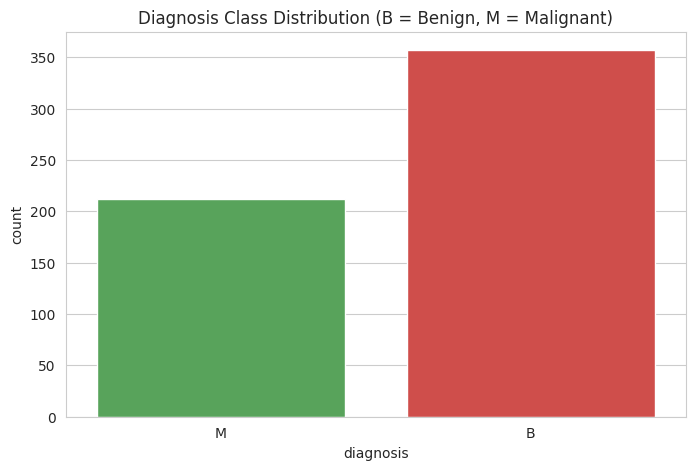

In [ ]:
plt.figure()
sns.countplot(data=df, x='diagnosis', palette=['#4CAF50', '#E53935'])
plt.title('Diagnosis Class Distribution (B = Benign, M = Malignant)')
plt.show()

In [ ]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


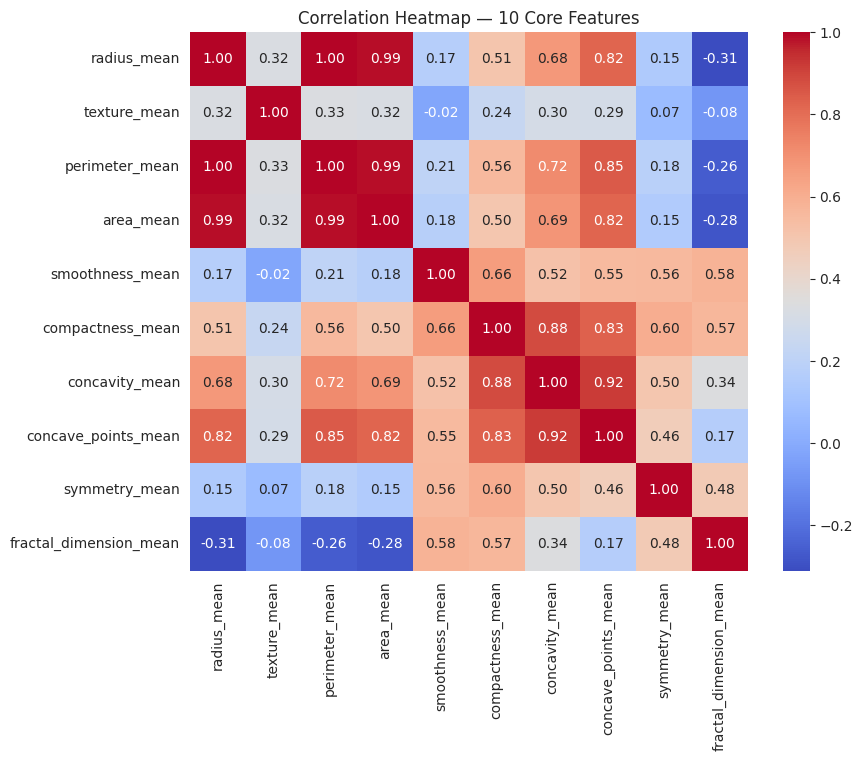

In [ ]:
# Keep only the 10 core MEAN features + target for this project
core_features = [f'{f}_mean' for f in feature_names]
df_model = df[['diagnosis'] + core_features].copy()
df_model['diagnosis'] = df_model['diagnosis'].map({'M': 1, 'B': 0})  # 1 = malignant

# Correlation heatmap of the 10 core features
plt.figure(figsize=(9, 7))
sns.heatmap(df_model[core_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap — 10 Core Features')
plt.show()


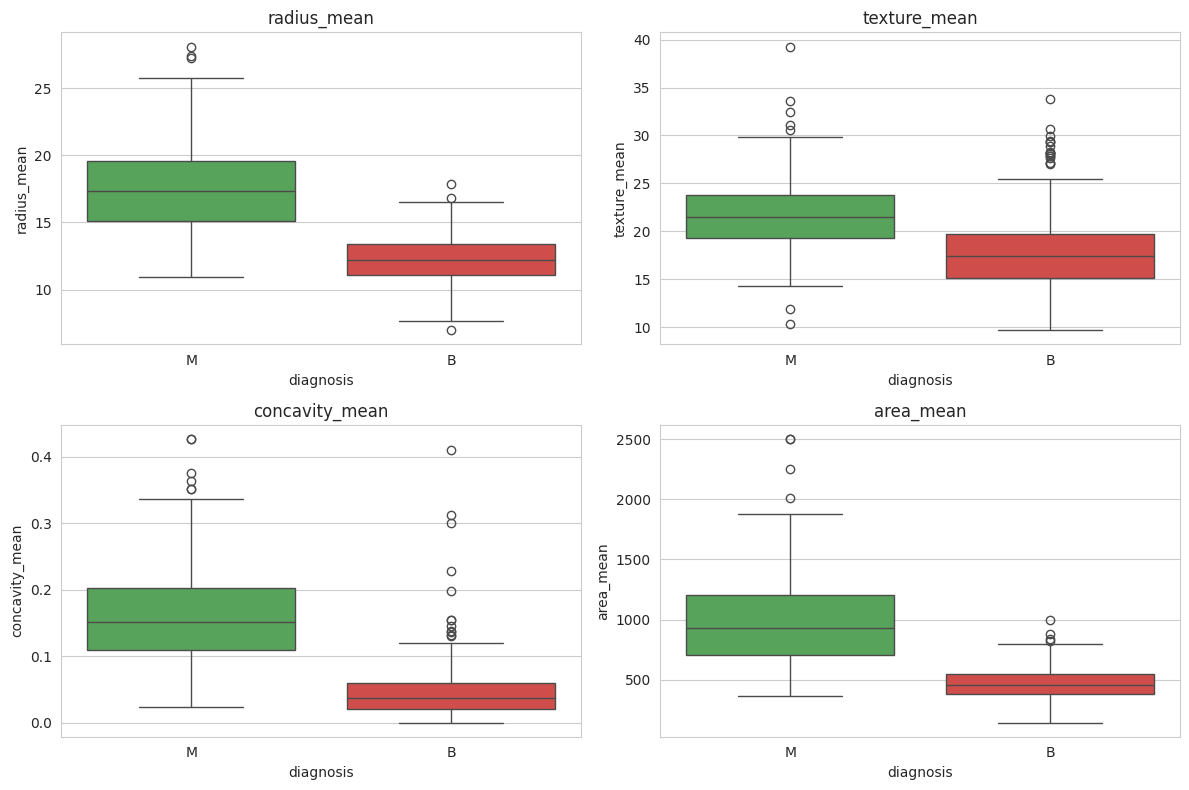

In [ ]:
# Distribution comparison for a few key features by diagnosis
key_feats = ['radius_mean', 'texture_mean', 'concavity_mean', 'area_mean']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), key_feats):
    sns.boxplot(data=df, x='diagnosis', y=feat, ax=ax, palette=['#4CAF50','#E53935'])
    ax.set_title(feat)
plt.tight_layout()
plt.show()

In [ ]:
X = df_model[core_features]
y = df_model['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=core_features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=core_features, index=X_test.index)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (455, 10)  Test shape: (114, 10)


In [ ]:
baseline = LogisticRegression(max_iter=5000, random_state=42)
baseline.fit(X_train_scaled, y_train)

print("=== Baseline: Logistic Regression ===")
print(classification_report(y_test, baseline.predict(X_test_scaled), target_names=['Benign', 'Malignant']))

=== Baseline: Logistic Regression ===
              precision    recall  f1-score   support

      Benign       0.96      0.93      0.94        72
   Malignant       0.89      0.93      0.91        42

    accuracy                           0.93       114
   macro avg       0.92      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



In [ ]:
et = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
xgb = XGBClassifier(n_estimators=300, use_label_encoder=False, eval_metric='logloss',
                     random_state=42, n_jobs=-1)

for name, model in [('Extra Trees', et), ('Random Forest', rf), ('XGBoost', xgb)]:
    model.fit(X_train, y_train)
    print(f"{name} trained.")

voting_ensemble = VotingClassifier(
    estimators=[('et', et), ('rf', rf), ('xgb', xgb)], voting='soft', n_jobs=-1
)
voting_ensemble.fit(X_train, y_train)
print("Voting ensemble trained.")

Extra Trees trained.
Random Forest trained.
XGBoost trained.
Voting ensemble trained.


                             Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                                    
Baseline (LogReg)              0.9298     0.8864  0.9286  0.9070   0.9841
Extra Trees                    0.9298     0.9048  0.9048  0.9048   0.9907
Random Forest                  0.9386     0.9268  0.9048  0.9157   0.9866
XGBoost                        0.9649     0.9524  0.9524  0.9524   0.9785
Voting Ensemble (ET+RF+XGB)    0.9561     0.9512  0.9286  0.9398   0.9901


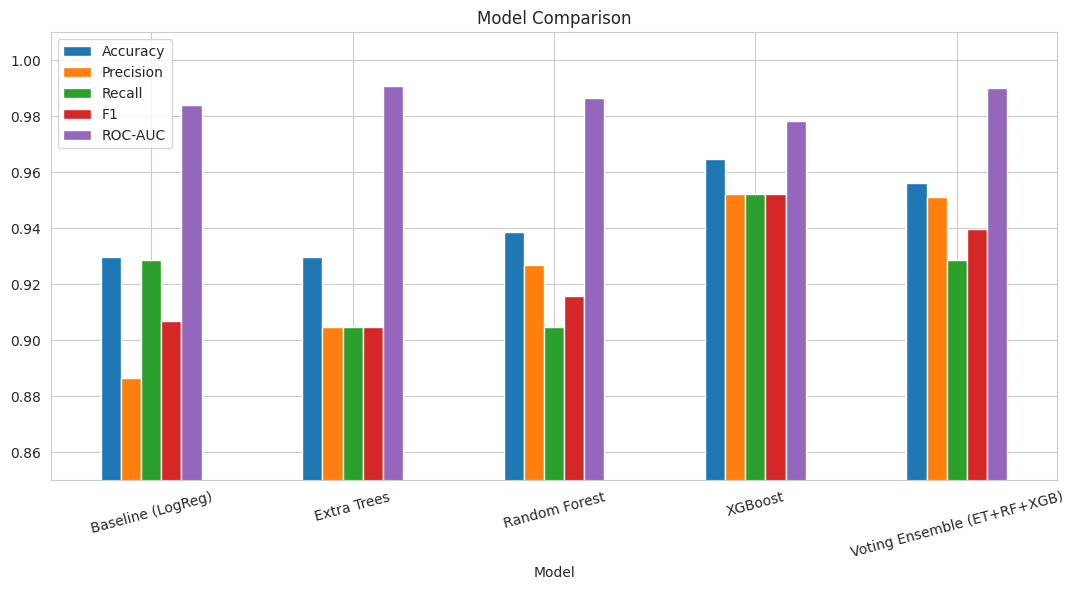

In [ ]:
def evaluate(name, model, X_te, y_te):
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    return {'Model': name, 'Accuracy': accuracy_score(y_te, pred),
            'Precision': precision_score(y_te, pred), 'Recall': recall_score(y_te, pred),
            'F1': f1_score(y_te, pred), 'ROC-AUC': roc_auc_score(y_te, proba)}

results = [
    evaluate('Baseline (LogReg)', baseline, X_test_scaled, y_test),
    evaluate('Extra Trees', et, X_test, y_test),
    evaluate('Random Forest', rf, X_test, y_test),
    evaluate('XGBoost', xgb, X_test, y_test),
    evaluate('Voting Ensemble (ET+RF+XGB)', voting_ensemble, X_test, y_test)
]
results_df = pd.DataFrame(results).set_index('Model').round(4)
print(results_df)

results_df.plot(kind='bar', figsize=(11, 6))
plt.title('Model Comparison')
plt.ylim(0.85, 1.01)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

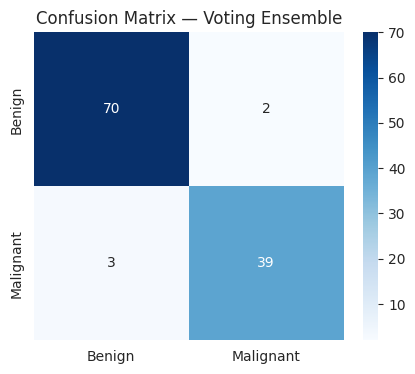

In [ ]:
# Confusion matrix + ROC curves
cm = confusion_matrix(y_test, voting_ensemble.predict(X_test))
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign','Malignant'], yticklabels=['Benign','Malignant'])
plt.title('Confusion Matrix — Voting Ensemble')
plt.show()


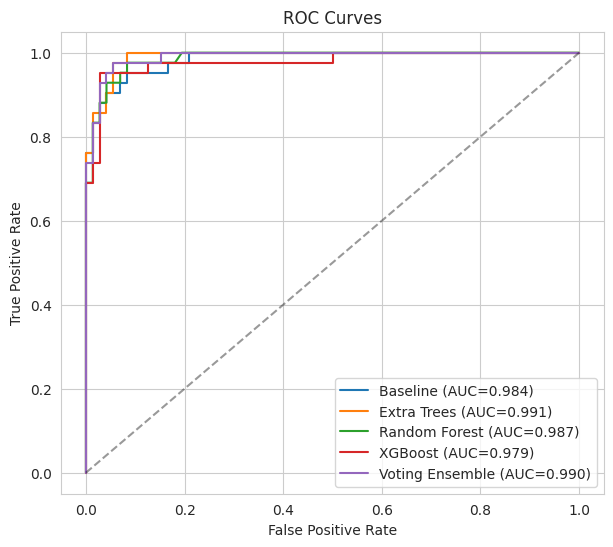

In [ ]:
plt.figure(figsize=(7,6))
for name, model, X_te in [('Baseline', baseline, X_test_scaled), ('Extra Trees', et, X_test),
                           ('Random Forest', rf, X_test), ('XGBoost', xgb, X_test),
                           ('Voting Ensemble', voting_ensemble, X_test)]:
    proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves'); plt.legend()
plt.show()

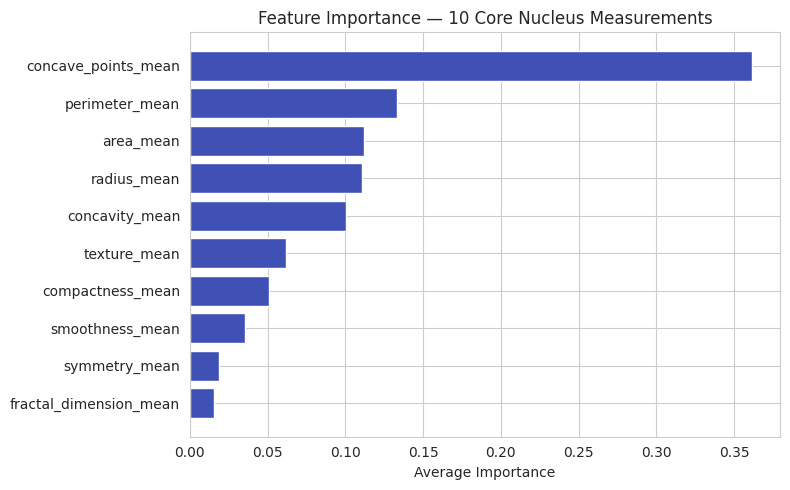

,Feature,Extra Trees,Random Forest,XGBoost,Average
7,concave_points_mean,0.199597,0.245340,0.639237,0.361391
2,perimeter_mean,0.161275,0.151314,0.086252,0.132947
3,area_mean,0.137647,0.156840,0.041990,0.112159
0,radius_mean,0.144529,0.127217,0.061122,0.110956
6,concavity_mean,0.124301,0.141888,0.035231,0.100473
1,texture_mean,0.061231,0.056399,0.067014,0.061548
5,compactness_mean,0.077357,0.056038,0.019608,0.051001
4,smoothness_mean,0.040390,0.032110,0.033985,0.035495
8,symmetry_mean,0.030215,0.017574,0.008072,0.018621
9,fractal_dimension_mean,0.023458,0.015279,0.007489,0.015409


In [ ]:
importance_df = pd.DataFrame({
    'Feature': core_features,
    'Extra Trees': et.feature_importances_,
    'Random Forest': rf.feature_importances_,
    'XGBoost': xgb.feature_importances_
})
importance_df['Average'] = importance_df[['Extra Trees','Random Forest','XGBoost']].mean(axis=1)
importance_df = importance_df.sort_values('Average', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(importance_df['Feature'][::-1], importance_df['Average'][::-1], color='#3F51B5')
plt.xlabel('Average Importance')
plt.title('Feature Importance — 10 Core Nucleus Measurements')
plt.tight_layout()
plt.show()

importance_df

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

feature_defaults = X.mean().to_dict()
feature_descriptions = {
    'radius_mean': 'Mean distance from center to perimeter points',
    'texture_mean': 'Std. dev. of gray-scale values',
    'perimeter_mean': 'Mean perimeter of nucleus',
    'area_mean': 'Mean area of nucleus',
    'smoothness_mean': 'Local variation in radius lengths',
    'compactness_mean': 'perimeter^2 / area - 1.0',
    'concavity_mean': 'Severity of concave portions of contour',
    'concave_points_mean': 'Number of concave portions of contour',
    'symmetry_mean': 'Symmetry of nucleus shape',
    'fractal_dimension_mean': '"Coastline approximation" - 1'
}

input_widgets = {}
box_children = [widgets.HTML("<h3>Enter the 10 Core Nucleus Measurements</h3>")]
for feat in core_features:
    w = widgets.FloatText(value=round(feature_defaults[feat], 5), description=feat.replace('_mean',''),
                           style={'description_width': '160px'}, layout=widgets.Layout(width='400px'))
    input_widgets[feat] = w
    box_children.append(widgets.HBox([w, widgets.HTML(f"<i style='color:gray'>{feature_descriptions[feat]}</i>")]))

form = widgets.VBox(box_children)
predict_btn = widgets.Button(description="🔍 Predict Diagnosis", button_style='primary')
output = widgets.Output()

def on_predict_click(b):
    with output:
        clear_output()
        row = {col: input_widgets[col].value for col in core_features}
        input_df = pd.DataFrame([row])[core_features]

        pred = voting_ensemble.predict(input_df)[0]
        proba = voting_ensemble.predict_proba(input_df)[0]
        benign_prob, malignant_prob = proba[0], proba[1]

        print("="*50)
        if pred == 1:
            print(f"🔴 PREDICTION: MALIGNANT   (probability: {malignant_prob*100:.1f}%)")
        else:
            print(f"🟢 PREDICTION: BENIGN   (probability: {benign_prob*100:.1f}%)")
        print("="*50)

        fig, ax = plt.subplots(figsize=(4,3))
        ax.bar(['Benign','Malignant'], [benign_prob, malignant_prob], color=['#4CAF50','#E53935'])
        ax.set_ylim(0,1); ax.set_ylabel('Probability')
        plt.show()
        print("\n⚠️  This is a machine learning demonstration, not a medical diagnosis.")

predict_btn.on_click(on_predict_click)
display(form, predict_btn, output)

Button(button_style='primary', description='🔍 Predict Diagnosis', style=ButtonStyle())

Output()

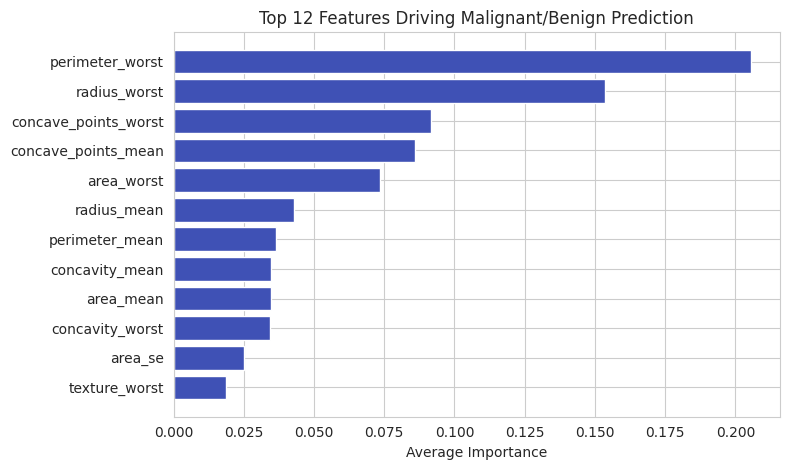

Higher values in 'worst' features (largest measurement per image) and
'concave points' most strongly indicate malignancy — reflecting larger,
more irregularly shaped cell nuclei.


In [ ]:
top_n = 12
top_features = importance_df.sort_values('Average', ascending=False).head(top_n)

plt.figure(figsize=(8, top_n*0.4))
plt.barh(top_features['Feature'][::-1], top_features['Average'][::-1], color='#3F51B5')
plt.xlabel('Average Importance')
plt.title(f'Top {top_n} Features Driving Malignant/Benign Prediction')
plt.tight_layout()
plt.show()

print("Higher values in 'worst' features (largest measurement per image) and")
print("'concave points' most strongly indicate malignancy — reflecting larger,")
print("more irregularly shaped cell nuclei.")